# 04 - Feature Engineering
## Sistema de Predicción Temprana de Plagas - Sierra del Patlachique

**Objetivo:** Crear indicadores y variables derivadas para predicción de plagas

**Responsabilidades (SOLO):**
- Variables de ventana temporal (rolling windows)
- Índices temáticos
- Indicadores de riesgo por plaga
- Nivel de alerta general
- Exportar datos con features

**NO hacer aquí:**
- Limpiar datos
- Análisis exploratorio

**Entrada:** `data/processed/datos_patlachique_clean.csv` (datos 100% limpios)

**Salida:** `data/features/datos_patlachique_features.csv` (con 20+ indicadores)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cargar datos limpios del notebook anterior
df = pd.read_csv("../data/processed/datos_patlachique_clean.csv",
                  index_col='fecha', parse_dates=True)

# Crear copia para agregar features
df_features = df.copy()

print(f"Datos limpios cargados: {df_features.shape}")
print(f"\t- Registros: {len(df_features)}")
print(f"\t- Variables: {df_features.shape[1]}")
print(f"\t- Período: {df_features.index.min().date()} a {df_features.index.max().date()}")

Datos limpios cargados: (817, 4)
	- Registros: 817
	- Variables: 4
	- Período: 2024-01-01 a 2026-03-27


## 1. VARIABLES DE VENTANA TEMPORAL

**¿Qué es?**
Crear variables que resumen comportamiento en períodos de tiempo (3, 7, 14, 21 días)

**¿Por qué?**
Las plagas responden a tendencias, no a valores puntuales
- Lluvia acumulada en 3 semanas (indica humedad del suelo)
- Días secos consecutivos (estrés hídrico)
- Temperatura promedio (actividad biológica)
- Humedad relativa mínima (períodos secos)

**Resultado esperado:**
11 nuevas variables derivadas de las 4 originales

In [2]:
print("\n" + "="*70)
print("1. CREANDO VARIABLES DE VENTANA TEMPORAL")
print("="*70)

# LLUVIA ACUMULADA (ventanas móviles)
print("\nLluvia acumulada en ventanas móviles...")
df_features['lluvia_3d']   = df_features['lluvia_mm'].rolling(window=3).sum()
df_features['lluvia_7d']   = df_features['lluvia_mm'].rolling(window=7).sum()
df_features['lluvia_14d']  = df_features['lluvia_mm'].rolling(window=14).sum()
df_features['lluvia_21d']  = df_features['lluvia_mm'].rolling(window=21).sum()

# DÍAS SECOS (lluvia < 0.1 mm se considera "sin lluvia")
print("Días secos consecutivos...")
df_features['dias_secos_7d']  = (df_features['lluvia_mm'] < 0.1).rolling(window=7).sum()
df_features['dias_secos_14d'] = (df_features['lluvia_mm'] < 0.1).rolling(window=14).sum()

# TEMPERATURA PROMEDIO
print("Temperatura promedio móvil...")
df_features['temp_media_7d']  = df_features['temp_media_C'].rolling(window=7).mean()
df_features['temp_media_14d'] = df_features['temp_media_C'].rolling(window=14).mean()

# HUMEDAD RELATIVA
print("Humedad relativa móvil...")
df_features['hr_media_7d']  = df_features['humedad_relativa_pct'].rolling(window=7).mean()
df_features['hr_minima_7d'] = df_features['humedad_relativa_pct'].rolling(window=7).min()

# DÍAS CON HUMEDAD RELATIVA BAJA (<70%)
print("Días con aire seco...")
df_features['dias_hr_baja_14d'] = (df_features['humedad_relativa_pct'] < 70).rolling(window=14).sum()

print("\nVariables de ventana temporal creadas:")
print("\tLluvia acumulada: 3d, 7d, 14d, 21d")
print("\tDías secos: 7d, 14d")
print("\tTemperatura promedio: 7d, 14d")
print("\tHumedad relativa: media 7d, mínima 7d, días HR<70% en 14d")
print(f"\n📈 Total de variables hasta ahora: {len(df_features.columns)}")


1. CREANDO VARIABLES DE VENTANA TEMPORAL

Lluvia acumulada en ventanas móviles...
Días secos consecutivos...
Temperatura promedio móvil...
Humedad relativa móvil...
Días con aire seco...

Variables de ventana temporal creadas:
	Lluvia acumulada: 3d, 7d, 14d, 21d
	Días secos: 7d, 14d
	Temperatura promedio: 7d, 14d
	Humedad relativa: media 7d, mínima 7d, días HR<70% en 14d

📈 Total de variables hasta ahora: 15


## 2. INDICADORES DE RIESGO POR PLAGA

**¿Qué es?**
Identificar cuándo las condiciones son favorables para cada plaga

**¿Por qué?**
Cada plaga tiene umbrales específicos de temperatura, humedad y sequía/lluvia

**Plagas monitoreadas:**
1. 🦗 **Chapulín (Spodoptera)** - Requiere humedad + pausa seca + temperatura
2. 🦟 **Pulgón** - Aire seco es factor de riesgo (extrae savia cuando está seco)
3. 🐛 **Gusano Cogollero** - Necesita humedad pero no lluvia torrencial (lavado)
4. 🕷️  **Araña Roja** - Ama aire seco y sequía prolongada

**Resultado esperado:**
4 nuevas columnas binarias (0=sin riesgo, 1=con riesgo)

In [3]:
print("\n" + "="*70)
print("2. INDICADORES DE RIESGO POR PLAGA")
print("="*70)

# 1. CHAPULÍN (Spodoptera)
print("\n🦗 CHAPULÍN:")
print("\tLógica: Humedad suficiente + Pausa seca + Temperatura moderada")
print("\tCondiciones:")
print("\t- Lluvia acumulada en 21 días > 8mm (humedad para eclosión)")
print("\t- Lluvia en últimos 3 días < 1.5mm (pausa seca para actividad)")
print("\t- Temperatura > 15°C (actividad biológica mínima)")

df_features['riesgo_chapulin'] = (
    (df_features['lluvia_21d'] > 8) &      # Humedad acumulada en 3 semanas
    (df_features['lluvia_3d']  < 1.5) &    # Pausa seca reciente
    (df_features['temp_media_C'] > 15)     # Temperatura de actividad
).astype(int)

print(f"\tDías con riesgo: {df_features['riesgo_chapulin'].sum()}")

# 2. PULGÓN
print("\n🦟 PULGÓN:")
print("\tLógica: Temperatura + Aire SECO + Lluvia baja")
print("\tCondiciones:")
print("\t- Temperatura > 14°C (actividad biológica)")
print("\t- Lluvia < 0.5mm (sin lluvia = sin lavado)")
print("\t- Humedad relativa < 70% (aire seco = estrés en planta = más ataque)")

df_features['riesgo_pulgon'] = (
    (df_features['temp_media_C'] > 14) &
    (df_features['lluvia_mm'] < 0.5) &
    (df_features['humedad_relativa_pct'] < 70)
).astype(int)

print(f"\tDías con riesgo: {df_features['riesgo_pulgon'].sum()}")

# 3. GUSANO COGOLLERO
print("\n🐛 GUSANO COGOLLERO:")
print("\tLógica: Temperatura + Humedad (pero no torrencial)")
print("\tCondiciones:")
print("\t- Temperatura > 14°C (desarrollo larval)")
print("\t- Lluvia en 7 días > 3mm (humedad para larvas)")
print("\t- Lluvia en 7 días < 60mm (excluye lluvias torrenciales = lavado)")

df_features['riesgo_cogollero'] = (
    (df_features['temp_media_C'] > 14) &
    (df_features['lluvia_7d'] > 3) &       # Humedad mínima para larvas
    (df_features['lluvia_7d'] < 60)        # Pero no torrencial (lavado)
).astype(int)

print(f"\tDías con riesgo: {df_features['riesgo_cogollero'].sum()}")

# 4. ARAÑA ROJA
print("\n🕷️  ARAÑA ROJA:")
print("\tLógica: Calor + Aire SECO + Sequía PROLONGADA")
print("\tCondiciones:")
print("\t- Temperatura > 17°C (estrés hídrico de la planta)")
print("\t- Humedad relativa < 60% (muy seco)")
print("\t- Al menos 10 días secos de los últimos 14 (sequía persistente)")

df_features['riesgo_arana_roja'] = (
    (df_features['temp_media_C'] > 17) &
    (df_features['humedad_relativa_pct'] < 60) &
    (df_features['dias_secos_14d'] >= 10)
).astype(int)

print(f"\tDías con riesgo: {df_features['riesgo_arana_roja'].sum()}")


2. INDICADORES DE RIESGO POR PLAGA

🦗 CHAPULÍN:
	Lógica: Humedad suficiente + Pausa seca + Temperatura moderada
	Condiciones:
	- Lluvia acumulada en 21 días > 8mm (humedad para eclosión)
	- Lluvia en últimos 3 días < 1.5mm (pausa seca para actividad)
	- Temperatura > 15°C (actividad biológica mínima)
	Días con riesgo: 77

🦟 PULGÓN:
	Lógica: Temperatura + Aire SECO + Lluvia baja
	Condiciones:
	- Temperatura > 14°C (actividad biológica)
	- Lluvia < 0.5mm (sin lluvia = sin lavado)
	- Humedad relativa < 70% (aire seco = estrés en planta = más ataque)
	Días con riesgo: 179

🐛 GUSANO COGOLLERO:
	Lógica: Temperatura + Humedad (pero no torrencial)
	Condiciones:
	- Temperatura > 14°C (desarrollo larval)
	- Lluvia en 7 días > 3mm (humedad para larvas)
	- Lluvia en 7 días < 60mm (excluye lluvias torrenciales = lavado)
	Días con riesgo: 283

🕷️  ARAÑA ROJA:
	Lógica: Calor + Aire SECO + Sequía PROLONGADA
	Condiciones:
	- Temperatura > 17°C (estrés hídrico de la planta)
	- Humedad relativa < 60% (m

## 3. NIVEL DE ALERTA GENERAL

**¿Qué es?**
Sumar cuántas plagas están en riesgo simultáneamente (escala 0-4)

**Categorías de alerta:**
- 🟢 **Verde:** 0 plagas en riesgo (sin intervención)
- 🟡 **Amarillo:** 1 plaga en riesgo (monitorear)
- 🟠 **Naranja:** 2 plagas en riesgo (considerar intervención)
- 🔴 **Rojo:** 3+ plagas en riesgo (intervención inmediata)

**Resultado esperado:**
- `nivel_alerta`: 0, 1, 2, 3 o 4
- `categoria_alerta`: Color + descripción
- 1 gráfica mostrando tendencia temporal


3. NIVEL DE ALERTA GENERAL

DISTRIBUCIÓN DE ALERTAS:
categoria_alerta
Amarillo (1 plaga)    290
Naranja (2 plagas)     96
Rojo (3+ plagas)       29
Verde (Sin riesgo)    402
Name: count, dtype: int64

ESTADÍSTICAS:
	Días con algún riesgo: 415
	Días críticos (3+ plagas): 29

Creando gráfica de tendencia de alertas...


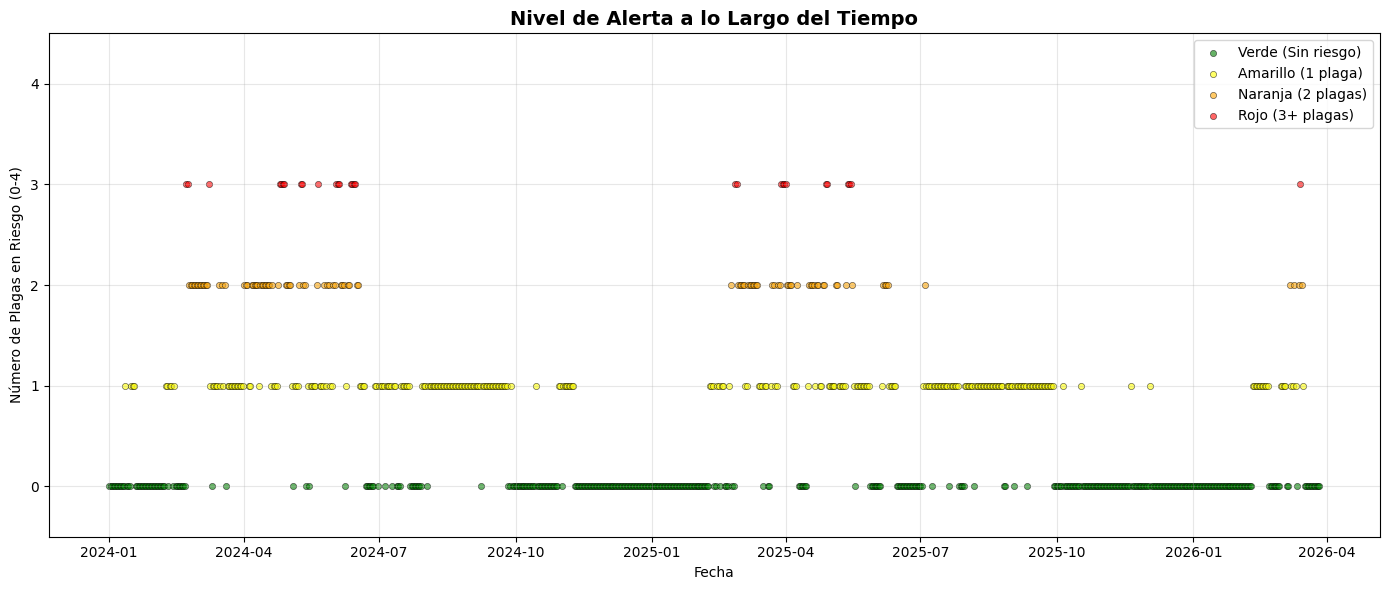

Gráfica guardada en reports/nivel_alerta.png


In [4]:
print("\n" + "="*70)
print("3. NIVEL DE ALERTA GENERAL")
print("="*70)

# Contar número de plagas en riesgo simultáneamente (0-4)
plagas = ['riesgo_chapulin', 'riesgo_pulgon', 'riesgo_cogollero', 'riesgo_arana_roja']
df_features['nivel_alerta'] = df_features[plagas].sum(axis=1)

# Crear categoría de alerta con colores
def categorizar_alerta(nivel):
    if nivel == 0:
        return 'Verde (Sin riesgo)'
    elif nivel == 1:
        return 'Amarillo (1 plaga)'
    elif nivel <= 2:
        return 'Naranja (2 plagas)'
    else:
        return 'Rojo (3+ plagas)'

df_features['categoria_alerta'] = df_features['nivel_alerta'].apply(categorizar_alerta)

# Estadísticas de alertas
print("\nDISTRIBUCIÓN DE ALERTAS:")
print(df_features['categoria_alerta'].value_counts().sort_index())
print(f"\nESTADÍSTICAS:")
print(f"\tDías con algún riesgo: {len(df_features[df_features['nivel_alerta'] > 0])}")
print(f"\tDías críticos (3+ plagas): {len(df_features[df_features['nivel_alerta'] >= 3])}")

# Visualizar tendencia de alerta a lo largo del tiempo
print("\nCreando gráfica de tendencia de alertas...")

fig, ax = plt.subplots(figsize=(14, 6))

# Colores para cada categoría
colors = {'Verde (Sin riesgo)': 'green',
          'Amarillo (1 plaga)': 'yellow',
          'Naranja (2 plagas)': 'orange',
          'Rojo (3+ plagas)': 'red'}

# Graficar cada categoría por separado (para colorear correctamente)
for cat in colors.keys():
    mask = df_features['categoria_alerta'] == cat
    ax.scatter(df_features.index[mask], df_features['nivel_alerta'][mask],
              label=cat, color=colors[cat], s=20, alpha=0.6, edgecolors='black', linewidth=0.5)

ax.set_title('Nivel de Alerta a lo Largo del Tiempo', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Plagas en Riesgo (0-4)')
ax.set_xlabel('Fecha')
ax.set_ylim([-0.5, 4.5])
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/reports/nivel_alerta.png", dpi=150, bbox_inches='tight')
plt.show()

print("Gráfica guardada en reports/nivel_alerta.png")

## 4. VISTA PREVIA Y VALIDACIÓN

**¿Qué hacemos?**
Verificar que todos los features se crearon correctamente

**Validaciones:**
- Forma del DataFrame (filas, columnas)
- Lista completa de variables
- Sin valores nulos
- Vista previa de datos

In [5]:
print("\n" + "="*70)
print("4. VISTA PREVIA Y VALIDACIÓN DE FEATURES")
print("="*70)

print(f"\nFORMA FINAL DEL DATASET:")
print(f"\tRegistros (filas): {df_features.shape[0]}")
print(f"\tVariables (columnas): {df_features.shape[1]}")

print(f"\n📈 DESGLOSE DE VARIABLES:")
print(f"\tOriginales: 4")
print(f"\tFeatures agregadas: {len(df_features.columns) - 4}")
print(f"\tTotal: {len(df_features.columns)}")

print("\n📋 LISTA COMPLETA DE VARIABLES:")
for i, col in enumerate(df_features.columns, 1):
    print(f"\t{i:2d}. {col}")

print("\nVALIDACIÓN DE DATOS FALTANTES:")
nulos_features = df_features.isnull().sum()
if nulos_features.sum() > 0:
    print("\tValores nulos encontrados:")
    print(nulos_features[nulos_features > 0])
else:
    print("\tSin valores nulos - PERFECTO")

print("\nMUESTRA DE DATOS (filas 30-34 con todos los features):")
print(df_features.iloc[30:35])

print("\nESTADÍSTICAS DE INDICADORES:")
print(f"\tDías con riesgo Chapulín: {df_features['riesgo_chapulin'].sum()}")
print(f"\tDías con riesgo Pulgón: {df_features['riesgo_pulgon'].sum()}")
print(f"\tDías con riesgo Cogollero: {df_features['riesgo_cogollero'].sum()}")
print(f"\tDías con riesgo Araña Roja: {df_features['riesgo_arana_roja'].sum()}")


4. VISTA PREVIA Y VALIDACIÓN DE FEATURES

FORMA FINAL DEL DATASET:
	Registros (filas): 817
	Variables (columnas): 21

📈 DESGLOSE DE VARIABLES:
	Originales: 4
	Features agregadas: 17
	Total: 21

📋 LISTA COMPLETA DE VARIABLES:
	 1. temp_media_C
	 2. lluvia_mm
	 3. humedad_suelo_frac
	 4. humedad_relativa_pct
	 5. lluvia_3d
	 6. lluvia_7d
	 7. lluvia_14d
	 8. lluvia_21d
	 9. dias_secos_7d
	10. dias_secos_14d
	11. temp_media_7d
	12. temp_media_14d
	13. hr_media_7d
	14. hr_minima_7d
	15. dias_hr_baja_14d
	16. riesgo_chapulin
	17. riesgo_pulgon
	18. riesgo_cogollero
	19. riesgo_arana_roja
	20. nivel_alerta
	21. categoria_alerta

VALIDACIÓN DE DATOS FALTANTES:
	Valores nulos encontrados:
lluvia_3d            2
lluvia_7d            6
lluvia_14d          13
lluvia_21d          20
dias_secos_7d        6
dias_secos_14d      13
temp_media_7d        6
temp_media_14d      13
hr_media_7d          6
hr_minima_7d         6
dias_hr_baja_14d    13
dtype: int64

MUESTRA DE DATOS (filas 30-34 con todos lo

## 5. EXPORTAR DATOS CON FEATURES

**¿Qué hacemos?**
Guardar el DataFrame con todos los features en un CSV

**Salida:**
- Archivo: `data/features/datos_patlachique_features.csv`
- Uso: Base para modelado predictivo, dashboards, alertas automáticas

**Próximos pasos:**
Con estos features listos, puedes:
- Entrenar modelos predictivos (Machine Learning)
- Crear dashboards interactivos
- Automatizar alertas de plagas
- Analizar patrones históricos

In [6]:
# Crear directorio si no existe
os.makedirs("../data/features", exist_ok=True)

print("\n" + "="*70)
print("5. EXPORTANDO DATOS CON FEATURES")
print("="*70)

# Guardar CSV
output_path = "../data/features/datos_patlachique_features.csv"
df_features.to_csv(output_path, index=True, encoding='utf-8')

# Verificar guardado
if os.path.exists(output_path):
    tamaño_kb = os.path.getsize(output_path) / 1024
    print(f"\nDATOS EXPORTADOS EXITOSAMENTE")
    print(f"\tRuta: {output_path}")
    print(f"\tTamaño: {tamaño_kb:.2f} KB")
    print(f"\tRegistros: {len(df_features)}")
    print(f"\tVariables: {len(df_features.columns)}")
else:
    print("\nERROR: No se pudo guardar el archivo")

print("\n" + "="*70)
print("PIPELINE COMPLETO")
print("="*70)
print("""
FÉLICIDADES - PROYECTO COMPLETADO

Tu dataset está listo para:
  Análisis estadístico avanzado
  Modelado predictivo (ML)
  Visualización en dashboards
  Automatización de alertas

Archivo generado:
  data/features/datos_patlachique_features.csv

Próximos pasos:
  1. Crear modelos predictivos (Notebook 05)
  2. Validar con datos históricos
  3. Generar dashboards
  4. Implementar alertas automáticas
""")


5. EXPORTANDO DATOS CON FEATURES

DATOS EXPORTADOS EXITOSAMENTE
	Ruta: ../data/features/datos_patlachique_features.csv
	Tamaño: 145.55 KB
	Registros: 817
	Variables: 21

PIPELINE COMPLETO

FÉLICIDADES - PROYECTO COMPLETADO

Tu dataset está listo para:
  Análisis estadístico avanzado
  Modelado predictivo (ML)
  Visualización en dashboards
  Automatización de alertas

Archivo generado:
  data/features/datos_patlachique_features.csv

Próximos pasos:
  1. Crear modelos predictivos (Notebook 05)
  2. Validar con datos históricos
  3. Generar dashboards
  4. Implementar alertas automáticas

